Raw dataset shape: (1508, 5)
          distance  trip_duration  num_passengers  time_of_day         fare
count  1508.000000    1483.000000     1508.000000  1508.000000  1508.000000
mean      5.033591      16.457393        1.990716    11.789070    18.480200
std       3.510594      12.376076        1.059563     6.920104    12.902656
min      -9.284648       1.000000        1.000000     0.000737     0.612385
25%       2.487817       7.482933        1.000000     5.696214    10.656919
50%       4.316915      13.554382        2.000000    11.648022    15.921878
75%       6.654180      22.377476        3.000000    17.734002    23.062683
max      22.772036      95.541165        4.000000    23.989385   240.826434

--- Cleaning ---
Removed 8 duplicate rows
Missing values per column:
trip_duration    25
dtype: int64
Removed 10 rows with invalid/negative values

--- Outlier handling (IQR method) ---
Removed 95 outlier rows
Clean dataset shape: (1395, 5)

--- Model training ---
Standardized coeffici

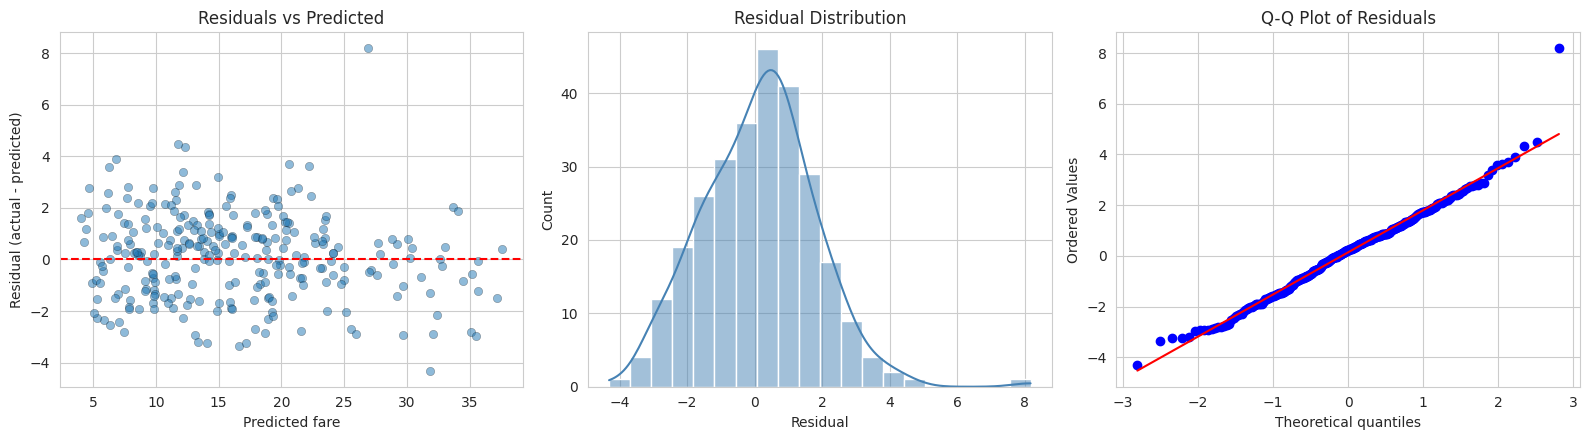

Residual mean: 0.138 (should be close to 0)
Residual std : 1.666


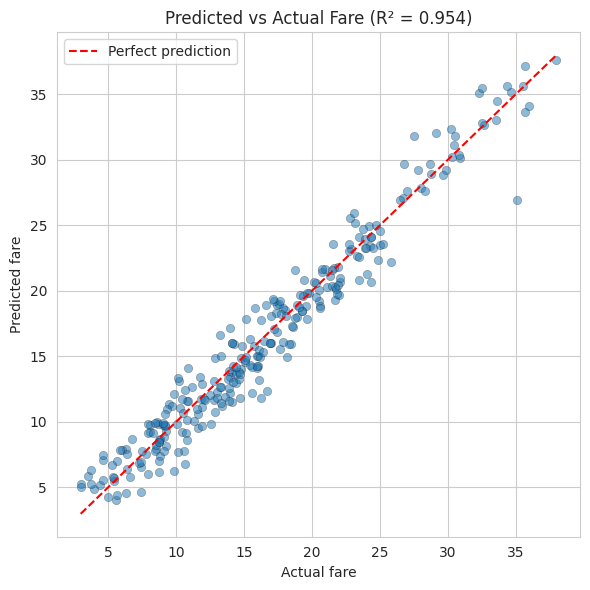


Sample comparison (first 10 rows):
 actual_fare  predicted_fare  error
       22.88           23.19  -0.31
       28.04           27.84   0.19
       20.54           20.09   0.45
       23.47           24.07  -0.61
        9.88           12.17  -2.29
       17.38           18.33  -0.95
       15.17           17.86  -2.69
       34.62           35.20  -0.58
       15.76           15.80  -0.04
       20.55           19.23   1.32


In [4]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---------------------------------------------------------------------
# 0. GENERATE A REALISTIC SYNTHETIC DATASET

N = 1500

distance = np.random.gamma(shape=2.0, scale=2.5, size=N)          # miles, right-skewed
time_of_day = np.random.uniform(0, 24, size=N)                     # hour of day (0-24)
num_passengers = np.random.choice([1, 1, 1, 2, 2, 3, 4], size=N)   # mostly 1-2

# duration correlates with distance but slows down in rush hour traffic
rush_hour_factor = 1 + 0.6 * np.exp(-((time_of_day - 8) ** 2) / 4) \
                      + 0.6 * np.exp(-((time_of_day - 18) ** 2) / 4)
trip_duration = distance * np.random.uniform(2.0, 3.5, size=N) * rush_hour_factor \
                + np.random.normal(0, 2, size=N)
trip_duration = np.clip(trip_duration, 1, None)

base_fare = 2.50
per_mile = 1.75
per_minute = 0.35
night_surcharge = np.where((time_of_day >= 22) | (time_of_day <= 5), 1.5, 0.0)

fare = (base_fare
        + per_mile * distance
        + per_minute * trip_duration
        + 0.5 * (num_passengers - 1)
        + night_surcharge
        + np.random.normal(0, 1.5, size=N))

df = pd.DataFrame({
    "distance": distance,
    "trip_duration": trip_duration,
    "num_passengers": num_passengers,
    "time_of_day": time_of_day,
    "fare": fare
})

# Inject realistic messiness: missing values + bad rows + extreme outliers
missing_idx = np.random.choice(df.index, size=25, replace=False)
df.loc[missing_idx, "trip_duration"] = np.nan

bad_idx = np.random.choice(df.index, size=10, replace=False)
df.loc[bad_idx, "distance"] = -abs(df.loc[bad_idx, "distance"])  # impossible negative distance

dup_rows = df.sample(8, random_state=RANDOM_STATE)
df = pd.concat([df, dup_rows], ignore_index=True)

outlier_idx = np.random.choice(df.index, size=6, replace=False)
df.loc[outlier_idx, "fare"] = df.loc[outlier_idx, "fare"] * np.random.uniform(6, 10, size=6)

print(f"Raw dataset shape: {df.shape}")
print(df.describe())

# ---------------------------------------------------------------------
# 1. CLEAN THE DATASET
# ---------------------------------------------------------------------
print("\n--- Cleaning ---")

n_before = len(df)
df = df.drop_duplicates()
print(f"Removed {n_before - len(df)} duplicate rows")

n_missing = df.isna().sum()
print(f"Missing values per column:\n{n_missing[n_missing > 0]}")
df["trip_duration"] = df["trip_duration"].fillna(df["trip_duration"].median())

n_before = len(df)
df = df[(df["distance"] > 0) & (df["trip_duration"] > 0) &
        (df["fare"] > 0) & (df["num_passengers"] > 0)]
print(f"Removed {n_before - len(df)} rows with invalid/negative values")

# ---------------------------------------------------------------------
# 2. HANDLE OUTLIERS (IQR method on distance, duration, fare)
# ---------------------------------------------------------------------
print("\n--- Outlier handling (IQR method) ---")

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

n_before = len(df)
for col in ["distance", "trip_duration", "fare"]:
    low, high = iqr_bounds(df[col])
    df = df[(df[col] >= low) & (df[col] <= high)]
print(f"Removed {n_before - len(df)} outlier rows")
print(f"Clean dataset shape: {df.shape}")

# ---------------------------------------------------------------------
# 3. BUILD LINEAR REGRESSION MODEL
# ---------------------------------------------------------------------
print("\n--- Model training ---")

features = ["distance", "trip_duration", "num_passengers", "time_of_day"]
X = df[features]
y = df["fare"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)
print("Standardized coefficients (relative importance):")
print(coef_df.to_string(index=False))
print(f"Intercept: {model.intercept_:.3f}")

# ---------------------------------------------------------------------
# 4. EVALUATE MODEL
# ---------------------------------------------------------------------
print("\n--- Evaluation ---")

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R^2  : {r2:.3f}")

# ---------------------------------------------------------------------
# 5. ANALYZE RESIDUALS
# ---------------------------------------------------------------------
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_pred, residuals, alpha=0.5, edgecolor="k", linewidth=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted fare")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=150)
plt.show()
print(f"Residual mean: {residuals.mean():.3f} (should be close to 0)")
print(f"Residual std : {residuals.std():.3f}")

# ---------------------------------------------------------------------
# 6. COMPARE PREDICTED VS ACTUAL FARE
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.5, edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual fare")
ax.set_ylabel("Predicted fare")
ax.set_title(f"Predicted vs Actual Fare (R² = {r2:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150)
plt.show()

comparison = pd.DataFrame({
    "actual_fare": y_test.values,
    "predicted_fare": y_pred,
    "error": y_test.values - y_pred
}).reset_index(drop=True)
comparison.to_csv("predicted_vs_actual.csv", index=False)
print("\nSample comparison (first 10 rows):")
print(comparison.head(10).round(2).to_string(index=False))